In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
'''import requests

url = "https://example.com/data.csv"
save_path = "/content/drive/MyDrive/data/data.csv"

response = requests.get(url)

with open(save_path, "wb") as f:
    f.write(response.content)'''

#!wget -O /content/drive/MyDrive/PatrolIQ/chicago_crimes_2001_present.csv \
"https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD"

--2026-01-25 09:32:55--  https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD
Resolving data.cityofchicago.org (data.cityofchicago.org)... 52.206.68.26, 52.206.140.199, 52.206.140.205
Connecting to data.cityofchicago.org (data.cityofchicago.org)|52.206.68.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘/content/drive/MyDrive/PatrolIQ/chicago_crimes_2001_present.csv’

/content/drive/MyDr     [              <=>   ]   1.87G  2.46MB/s    in 11m 37s 

2026-01-25 09:44:32 (2.75 MB/s) - ‘/content/drive/MyDrive/PatrolIQ/chicago_crimes_2001_present.csv’ saved [2005230132]



In [6]:
'''import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/PatrolIQ/chicago_crimes_2001_present.csv")
df.shape'''


/tmp/ipython-input-1402960295.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/drive/MyDrive/PatrolIQ/chicago_crimes_2001_present.csv")


(8483375, 22)

In [13]:
'''df_recent = (
    df.sort_values("Date", ascending=False)
      .head(500_000)
)

df_recent.to_csv("/content/drive/MyDrive/PatrolIQ/Chicago_Crimes_Recent_500k.csv", index=False)'''


In [2]:
import pandas as pd
df_recent=pd.read_csv("/content/drive/MyDrive/PatrolIQ/Chicago_Crimes_Recent_500k.csv")
df_recent.shape

(500000, 22)

In [3]:
df_recent.shape

(500000, 22)

In [4]:
df_recent.dtypes

,0
ID,int64
Case Number,object
Date,object
Block,object
IUCR,object
Primary Type,object
Description,object
Location Description,object
Arrest,bool
Domestic,bool


In [5]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
df_recent.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14070406,JJ540157,12/31/2025 12:56:00 PM,033XX W SUNNYSIDE AVE,0560,ASSAULT,SIMPLE,RESIDENCE - PORCH / HALLWAY,False,False,1724,17.0,33.0,14.0,08A,1153139.0,1929707.0,2025,01/08/2026 03:46:48 PM,41.962967,-87.712351,"(41.962966913, -87.712351374)"
1,14070068,JJ539766,12/31/2025 12:56:00 AM,048XX W MONROE ST,1750,OFFENSE INVOLVING CHILDREN,CHILD ABUSE,APARTMENT,True,True,1533,15.0,28.0,25.0,08B,1144196.0,1899224.0,2025,01/08/2026 03:46:48 PM,41.879492,-87.745999,"(41.87949161, -87.745999461)"
2,14070069,JJ539768,12/31/2025 12:55:00 AM,011XX S LAFLIN ST,1780,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,CHA APARTMENT,False,True,1231,12.0,28.0,28.0,20,1166546.0,1895280.0,2025,01/08/2026 03:46:48 PM,41.868220,-87.664047,"(41.868219921, -87.664046556)"
3,14070346,JJ540155,12/31/2025 12:50:00 PM,044XX N LINCOLN AVE,1330,CRIMINAL TRESPASS,TO LAND,LIBRARY,True,False,1911,19.0,47.0,4.0,26,1160731.0,1929529.0,2025,01/08/2026 03:46:48 PM,41.962324,-87.684443,"(41.962324098, -87.684443267)"
4,14070423,JJ540254,12/31/2025 12:49:00 PM,075XX N PAULINA ST,4650,OTHER OFFENSE,SEX OFFENDER - FAIL TO REGISTER,SIDEWALK,True,False,2422,24.0,49.0,1.0,26,1163669.0,1950095.0,2025,01/21/2026 03:42:01 PM,42.018696,-87.673058,"(42.018696268, -87.673058465)"


In [7]:
df0=df_recent.drop(columns=['ID','Case Number','IUCR','FBI Code','Updated On','Block','Latitude','Longitude','X Coordinate','Y Coordinate','Location'])

In [8]:
df0.shape

(500000, 11)

In [10]:
df0.head()

,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year
0,12/31/2025 12:56:00 PM,ASSAULT,SIMPLE,RESIDENCE - PORCH / HALLWAY,False,False,1724,17.0,33.0,14.0,2025
1,12/31/2025 12:56:00 AM,OFFENSE INVOLVING CHILDREN,CHILD ABUSE,APARTMENT,True,True,1533,15.0,28.0,25.0,2025
2,12/31/2025 12:55:00 AM,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,CHA APARTMENT,False,True,1231,12.0,28.0,28.0,2025
3,12/31/2025 12:50:00 PM,CRIMINAL TRESPASS,TO LAND,LIBRARY,True,False,1911,19.0,47.0,4.0,2025
4,12/31/2025 12:49:00 PM,OTHER OFFENSE,SEX OFFENDER - FAIL TO REGISTER,SIDEWALK,True,False,2422,24.0,49.0,1.0,2025


In [12]:
df0['Date'] = pd.to_datetime(df0['Date'], errors='coerce')

In [13]:
# Temporal features
df0['Hour'] = df0['Date'].dt.hour
df0['Day_of_Week'] = df0['Date'].dt.day_name()
df0['Month'] = df0['Date'].dt.month
df0['Is_Weekend'] = df0['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)




,Hour,Day_of_Week,Month,Is_Weekend
0,12,Wednesday,12,0
1,0,Wednesday,12,0
2,0,Wednesday,12,0
3,12,Wednesday,12,0
4,12,Wednesday,12,0


In [15]:
df0[['Date','Hour', 'Day_of_Week', 'Month', 'Is_Weekend']].head(10)

,Date,Hour,Day_of_Week,Month,Is_Weekend
0,2025-12-31 12:56:00,12,Wednesday,12,0
1,2025-12-31 00:56:00,0,Wednesday,12,0
2,2025-12-31 00:55:00,0,Wednesday,12,0
3,2025-12-31 12:50:00,12,Wednesday,12,0
4,2025-12-31 12:49:00,12,Wednesday,12,0
5,2025-12-31 00:48:00,0,Wednesday,12,0
6,2025-12-31 12:46:00,12,Wednesday,12,0
7,2025-12-31 00:45:00,0,Wednesday,12,0
8,2025-12-31 12:40:00,12,Wednesday,12,0
9,2025-12-31 12:39:00,12,Wednesday,12,0


In [16]:
df0.drop(columns=['Date'],inplace=True)

In [17]:
df0.isnull().sum()

,0
Primary Type,0
Description,0
Location Description,923
Arrest,0
Domestic,0
Beat,0
District,1
Ward,27091
Community Area,27096
Year,0


In [21]:
df0.dropna(subset=['Location Description'],inplace=True)

In [25]:
df0.dropna(subset=['Ward','Community Area'],inplace=True)

In [27]:
df0.duplicated().sum()

np.int64(5489)

In [28]:
df0 = df0.drop_duplicates()

In [29]:
df0.head()

,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Hour,Day_of_Week,Month,Is_Weekend
0,ASSAULT,SIMPLE,RESIDENCE - PORCH / HALLWAY,False,False,1724,17.0,33.0,14.0,2025,12,Wednesday,12,0
1,OFFENSE INVOLVING CHILDREN,CHILD ABUSE,APARTMENT,True,True,1533,15.0,28.0,25.0,2025,0,Wednesday,12,0
2,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,CHA APARTMENT,False,True,1231,12.0,28.0,28.0,2025,0,Wednesday,12,0
3,CRIMINAL TRESPASS,TO LAND,LIBRARY,True,False,1911,19.0,47.0,4.0,2025,12,Wednesday,12,0
4,OTHER OFFENSE,SEX OFFENDER - FAIL TO REGISTER,SIDEWALK,True,False,2422,24.0,49.0,1.0,2025,12,Wednesday,12,0


In [34]:
df0.drop(columns='Description',inplace=True)

In [33]:
df0['Primary Type'].value_counts()

,count
Primary Type,
THEFT,102965
BATTERY,80344
CRIMINAL DAMAGE,51504
NARCOTICS,37930
ASSAULT,29053
OTHER OFFENSE,28579
BURGLARY,28422
MOTOR VEHICLE THEFT,27570
DECEPTIVE PRACTICE,23760


In [35]:
df0['Location Description'].value_counts()

,count
Location Description,
STREET,114992
RESIDENCE,78939
APARTMENT,65498
SIDEWALK,36154
OTHER,14409
SMALL RETAIL STORE,11398
PARKING LOT/GARAGE(NON.RESID.),11068
RESTAURANT,9149
ALLEY,8805


In [38]:
freq = df0["Location Description"].value_counts(normalize=True)
freq

,proportion
Location Description,
STREET,0.246551
RESIDENCE,0.169251
APARTMENT,0.140433
SIDEWALK,0.077517
OTHER,0.030894
SMALL RETAIL STORE,0.024438
PARKING LOT/GARAGE(NON.RESID.),0.023731
RESTAURANT,0.019616
ALLEY,0.018879


In [39]:
def group_location(x):
    x = x.upper()
    if "RESIDENCE" in x or "APARTMENT" in x or "HOUSE" in x:
        return "RESIDENTIAL"
    elif "STREET" in x or "SIDEWALK" in x or "ALLEY" in x:
        return "PUBLIC_OUTDOOR"
    elif "STORE" in x or "RESTAURANT" in x or "BAR" in x:
        return "COMMERCIAL"
    elif "SCHOOL" in x or "COLLEGE" in x:
        return "EDUCATION"
    elif "CTA" in x or "TRAIN" in x or "BUS" in x:
        return "TRANSPORT"
    else:
        return "OTHER"

df0["location_group"] = df0["Location Description"].apply(group_location)


In [40]:
df0["location_group"].value_counts()

,count
location_group,
RESIDENTIAL,164231
PUBLIC_OUTDOOR,160006
OTHER,74457
COMMERCIAL,44881
TRANSPORT,11697
EDUCATION,11130


In [43]:
df0.drop(columns='Location Description' , inplace =True)

In [44]:
# Identify categorical and pseudo-categorical columns
categorical_cols = df0.select_dtypes(
    include=['object', 'category']
).columns.tolist()
pseudo_categorical = [
    col for col in df0.select_dtypes(include=['int64', 'float64']).columns
    if df0[col].nunique() < 15
]

#pseudo_categorical
all_categorical_cols = categorical_cols + pseudo_categorical
df0[all_categorical_cols].head()

,Primary Type,Day_of_Week,location_group,Is_Weekend
0,ASSAULT,Wednesday,RESIDENTIAL,0
1,OFFENSE INVOLVING CHILDREN,Wednesday,RESIDENTIAL,0
2,OFFENSE INVOLVING CHILDREN,Wednesday,RESIDENTIAL,0
3,CRIMINAL TRESPASS,Wednesday,OTHER,0
4,OTHER OFFENSE,Wednesday,PUBLIC_OUTDOOR,0


In [45]:
# Label Encode ordinal data columns
df0['Day_of_Week'] = df0['Day_of_Week'].str.strip().str.title()
Day_of_Week_map = {
    'Sunday': 0,
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6

}

df0['Day_enc'] = df0['Day_of_Week'].map(Day_of_Week_map)
df0['Day_enc'].value_counts(dropna=False)


,count
Day_enc,
5,70636
3,67212
1,67058
6,66910
2,66062
4,65958
0,62566


In [46]:
df0.drop(columns=['Day_of_Week'],inplace=True)

In [47]:
df0['Primary Type'] = (
    df0['Primary Type']
    .str.strip()
    .str.title()
)

df0['location_group'] = (
    df0['location_group']
    .str.strip()
    .str.upper()
)
df0 = pd.get_dummies(
    df0,
    columns=['Primary Type'],
    prefix=['primary'],
    drop_first=False
)



In [49]:
loc_freq = df0["location_group"].value_counts(normalize=True)
loc_freq

,proportion
location_group,
RESIDENTIAL,0.352123
PUBLIC_OUTDOOR,0.343065
OTHER,0.159641
COMMERCIAL,0.096228
TRANSPORT,0.025079
EDUCATION,0.023864


In [50]:
df0['location_freq'] = df0['location_group'].map(loc_freq)

In [52]:
df0.drop(columns=['location_group'], inplace=True)

In [55]:
df0.head()

,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Hour,Month,Is_Weekend,Day_enc,primary_Arson,primary_Assault,primary_Battery,primary_Burglary,primary_Concealed Carry License Violation,primary_Crim Sexual Assault,primary_Criminal Damage,primary_Criminal Sexual Assault,primary_Criminal Trespass,primary_Deceptive Practice,primary_Gambling,primary_Homicide,primary_Human Trafficking,primary_Interference With Public Officer,primary_Intimidation,primary_Kidnapping,primary_Liquor Law Violation,primary_Motor Vehicle Theft,primary_Narcotics,primary_Non-Criminal,primary_Obscenity,primary_Offense Involving Children,primary_Other Narcotic Violation,primary_Other Offense,primary_Prostitution,primary_Public Indecency,primary_Public Peace Violation,primary_Ritualism,primary_Robbery,primary_Sex Offense,primary_Stalking,primary_Theft,primary_Weapons Violation,location_freq
0,0,0,1724,17.0,33.0,14.0,2025,12,12,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.352123
1,1,1,1533,15.0,28.0,25.0,2025,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.352123
2,0,1,1231,12.0,28.0,28.0,2025,0,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.352123
3,1,0,1911,19.0,47.0,4.0,2025,12,12,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.159641
4,1,0,2422,24.0,49.0,1.0,2025,12,12,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.343065


In [54]:
bool_cols = df0.select_dtypes(include='bool').columns

df0[bool_cols] = df0[bool_cols].astype(int)


In [56]:
assert df0['Hour'].between(0, 23).all()
assert df0['Month'].between(1, 12).all()
assert df0['Year'].between(2001, 2025).all()
assert df0['location_freq'].between(0, 1).all()


In [57]:
Q1 = df0['location_freq'].quantile(0.25)
Q3 = df0['location_freq'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df0[
    (df0['location_freq'] < Q1 - 1.5 * IQR) |
    (df0['location_freq'] > Q3 + 1.5 * IQR)
]

print(len(outliers_iqr))


0


In [ ]:
features = [
    'Beat', 'District', 'Ward', 'Community Area',
    'Hour', 'Month', 'Day_enc',
    'location_freq',
    'Arrest', 'Domestic', 'Is_Weekend'
]


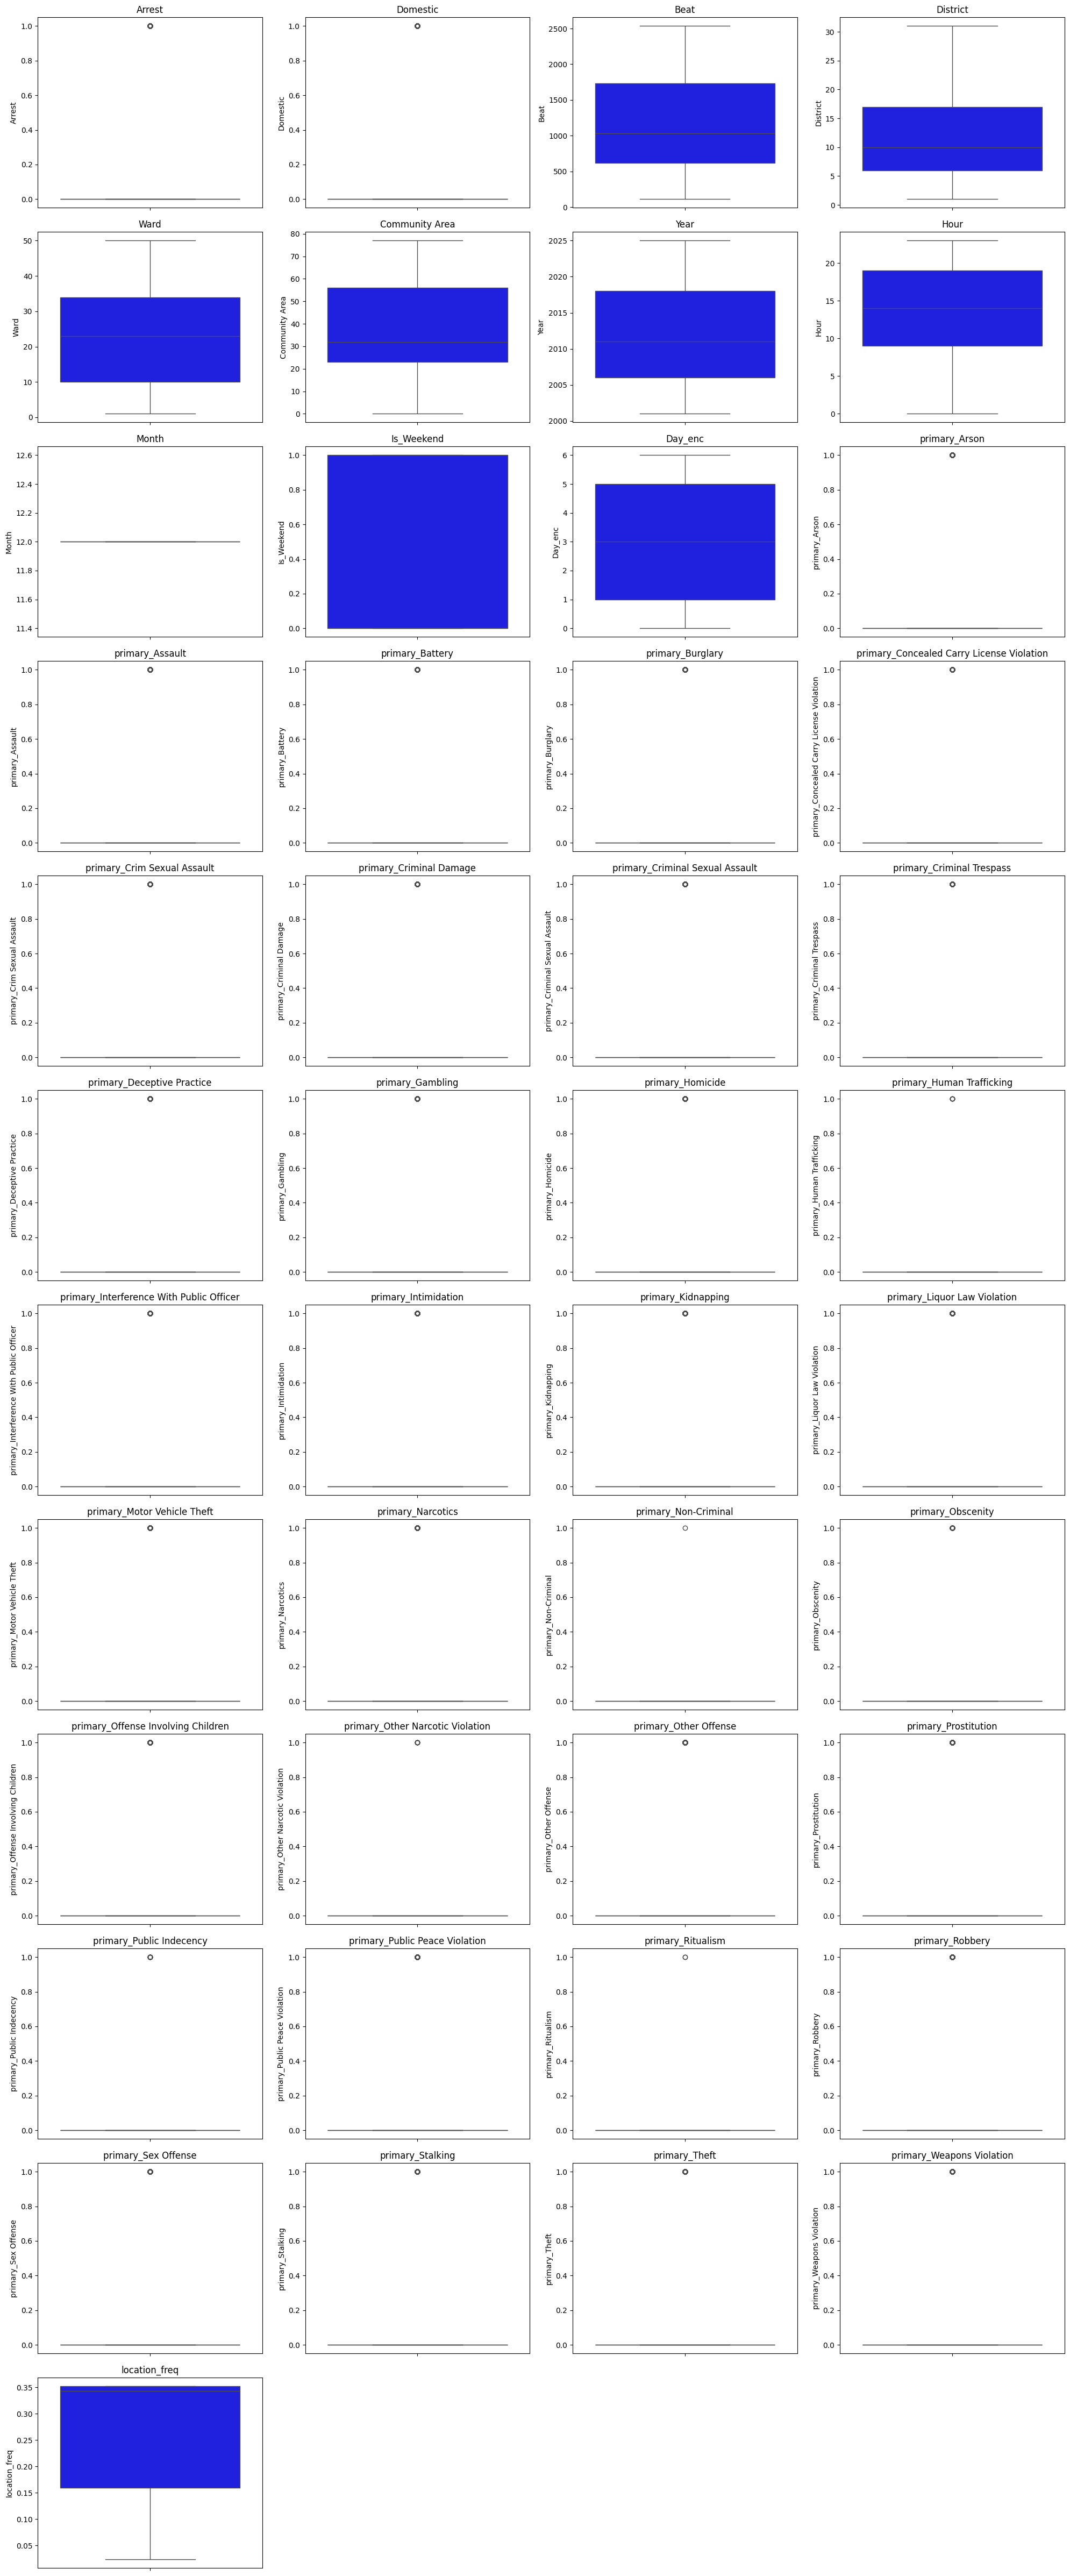

In [59]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

float_features = df0.select_dtypes(exclude=['bool']).columns

n_cols = 4
n_rows = math.ceil(len(float_features) / n_cols)

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, feature in enumerate(float_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df0[feature], color='blue')
    plt.title(feature)

plt.tight_layout()
plt.show()

In [61]:
df0.shape

(466402, 45)

In [62]:
df0.to_csv("/content/drive/MyDrive/PatrolIQ/PatrolIQ_cleaned.csv")